# Curso de Optimización
## Tarea 8

| Descripción:                         | Fechas               |
|--------------------------------------|----------------------|
| Fecha de publicación del documento:  | **Abril 29, 2025**   |
| Fecha límite de entrega de la tarea: | **Mayo  8, 2025**   |


### Indicaciones

Puede escribir el código de los algoritmos que se piden en una
celda de este notebook o si lo prefiere, escribir las funciones
en un archivo `.py` independiente e importar la funciones para
usarlas en este notebook. Lo importante es que en el notebook
aparezcan los resultados de la pruebas realizadas y que:

- Si se requieren otros archivos para poder reproducir los resultados,
  para mandar la tarea cree un archivo ZIP en el que incluya
  el notebook y los archivos adicionales.
- Si todos los códigos para que se requieren para reproducir los
  resultados están en el notebook, no hace falta comprimirlo
  y puede anexar sólo el notebook en la tarea.
- Exportar el notebook a un archivo PDF y anexarlo en la tarea como un archivo independiente.
  **No lo incluya dentro del ZIP**, porque la idea que lo pueda accesar
  directamente para poner anotaciones y la calificación de cada ejercicio.

---

## Ejercicio 1. Mínimos cuadrados lineales (2 puntos)

Encontrar los coeficientes $c_0, c_1, ...$ de un polinomio de dos variables
$p_n(x_1, x_2)$ de grado $n$ que resuelve el problema de mínimos
cuadrados lineales:

$$ \min_{c_i} \sum_{i=1}^m [p_n(x_{1i}, x_{2i}) - y_i]^2.  $$

El conjunto de datos $\{ (x_{11}, x_{21}, y_1), (x_{12}, x_{22}, y_2),
..., (x_{1m}, x_{2m}, y_m)\}$ está generado como se muestra en el
siguiente código. Las coordenadas de las variables $x_1$ y $x_2$
están almacenadas como columnas en el arreglo $\mathbf{X}$ y los
valores $y_i$ se almacenan en el arreglo $\mathbf{y}$:

$$ \mathbf{X} = \begin{bmatrix} x_{11} & x_{21} \\
x_{12} & x_{22} \\
\vdots & \vdots \\
x_{1m} & x_{2m}
\end{bmatrix}, \quad
\mathbf{y} = \begin{pmatrix}
y_1 \\ y_2 \\ \vdots \\ y_m
\end{pmatrix}.
$$


(144, 2)
(144,)


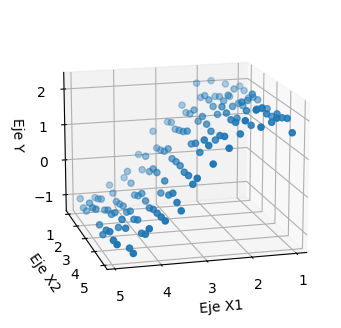

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

# Generate the true function and the data set
np.random.seed(42)
true_function = lambda x: 1.5*np.sin(x[0]) + 0.5

x1 = np.array([i*np.pi/180 for i in range(60,300,20)])
x2 = np.linspace(1,5,len(x1))
x1_grid,x2_grid = np.meshgrid(x1,x2)
m  = len(x1)*len(x2)
X  = np.zeros((m,2))
X[:,0]  = x1_grid.flatten()
X[:,1]  = x2_grid.flatten()
print(X.shape)
y = np.zeros(m)
for i,x1x2 in enumerate(X):
    y[i] = true_function(x1x2)
y += np.random.normal(0, 0.15, m)
print(y.shape)
# Grafica del conjunto de datos
fig = plt.figure(figsize=(6,4))
ax = plt.axes(projection='3d')
ax.scatter3D(X[:,0], X[:,1], y)
ax.set_xlabel('Eje X1')
ax.set_ylabel('Eje X2')
ax.set_zlabel('Eje Y')
ax.view_init(15, 75)

El polinomio $p_n(x_1, x_2)$ de grado $n$ es de la forma

$$ p_n(x_1, x_2) = \sum_{i_1 =0}^n
\sum_{i_2=0}^{n-i_1}  c_i x_1^{i_1}x_2^{i_2},$$

es decir, el polinomio está formado por los términos $c_i x_1^{i_1}x_2^{i_2}$,
donde $i$ indexa cada término.

Ejemplos:

$$ p_1(x_1, x_2) = c_0 + c_1 x_1 + c_2 x_2$$

$$ p_2(x_1, x_2) = c_0 + c_1 x_1 + c_2 x_2 + c_3x_1x_2 + c_4 x_1^2 +
c_5 x_2^2$$

Entonces

$$  \sum_{i=1}^m [p_n(x_{1i}, x_{2i}) - y_i]^2
=  (\mathbf{X}_n \mathbf{c}-\mathbf{y})^\top (\mathbf{X}_n \mathbf{c}-\mathbf{y})   $$

donde $\mathbf{c}= (c_0, c_1, ..., c_r)^\top$ es el vector de coeficientes
del polinomio, $r+1$ es la cantidad de coeficientes y $\mathbf{X}_n$
es la matriz que tiene en cada columna los valores

$$\begin{array}{c}
x_{11}^{i_1}x_{21}^{i_2} \\  
x_{12}^{i_1}x_{22}^{i_2} \\  
\vdots \\
x_{1m}^{i_1}x_{2m}^{i_2}
\end{array}$$

Para generar generar la matriz $\mathbf{X}_n$  se puede usar la
clase `PolynomialFeatures`. Por ejemplo, crear la matriz $\mathbf{X}_3$
asociada al polinomio de grado 3:   

In [3]:
from sklearn.preprocessing import PolynomialFeatures

n    = 3
poly = PolynomialFeatures(n, include_bias=True)
Xn   = poly.fit_transform(X)
print('Tamaño de la matriz Xn:', Xn.shape)

Tamaño de la matriz Xn: (144, 10)


De acuerdo con la teoría, la solución $\mathbf{c}$ del problema
de mínimos cuadrados se obtiene resolviendo el sistema de ecuaciones

$$ \mathbf{X}_n^\top\mathbf{X}_n\mathbf{c} = \mathbf{X}_n^\top\mathbf{y}$$

Dado el vector $\mathbf{c}$, los valores del polinomio en los
puntos $(x_{1i}, x_{2i})$ están dados por

$$ \mathbf{y}_{pred} = \mathbf{X}_n\mathbf{c},$$

y la raíz del error cuadrático medio entre los valores verdaderos
y los que predice el modelo está dado por

$$
RMSE = \sqrt{\frac{(\mathbf{y}-\mathbf{y}_{pred})^\top(\mathbf{y}-\mathbf{y}_{pred})}{m}}.
$$


1. Escriba una función que reciba como argumentos la matriz  
   $\mathbf{X}$, el vector $\mathbf{y}$ y el grado $n$ del polinomio.
   La función devuelve el vector de coeficientes $\mathbf{c}$
   del polinomio $p_n(x_1,x_2)$ y el número de condición
   de la matriz $\mathbf{X}_n$.
2. Pruebe la función para $n=1,3, 5$ y $7$.
   En cada caso calcule el vector $\mathbf{y}_{pred}$,  el RMSE e imprima
   los valores:
   
- El grado $n$ del polinomio
- El número de condición de la matriz $\mathbf{X}_n$
- El RMSE

Puede usar el siguiente código para graficar la superficie
del polinomio usando los valores que toma en los nodos de la
retícula:

```
Y_grid  = y_pred.reshape( len(x1), len(x2) )
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')
ax.plot_surface(x1_grid, x2_grid, Y_grid, rstride=1, cstride=1, cmap='coolwarm', edgecolor='none')
ax.scatter3D(X[:,0], X[:,1], y)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.view_init(15, 75)
```

### Solución:

In [ ]:

def fun_1_1(X,y,n):
    poly=PolynomialFeatures(n,include_bias=True)
    Xn=poly.fit_transform(X)
    print('Tamaño de la matriz Xn:', Xn.shape)
    A=np.dot(Xn.T,Xn)
    print(A.shape)
    b=np.dot(Xn.T,y)
    print(b.shape)
    c=np.linalg.solve(A,b)
    return Xn, c

def fun_1_2(y,y_pred):
    RMSE=np.sqrt(np.dot(y-y_pred,y-y_pred)/m)
    return RMSE

def fun_1_3(y_pred,n,prob):
    Y_grid=y_pred.reshape( len(x1), len(x2) )
    fig=plt.figure(figsize=(8,6))
    ax=plt.axes(projection='3d')
    ax.plot_surface(x1_grid,x2_grid,Y_grid,rstride=1,cstride=1,cmap='coolwarm', edgecolor='none')
    ax.scatter3D(X[:,0], X[:,1], y)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('Y')
    ax.view_init(15, 75)
    plt.savefig("pro_"+prob+"_3_"+str(n)+".pdf")
    plt.show()

def fun_1_4(A):
    U,S,Vt=np.linalg.svd(A)
    numero_condicion=S[0]/S[-1]  
    return numero_condicion

Tamaño de la matriz Xn: (144, 3)
(3, 3)
(3,)


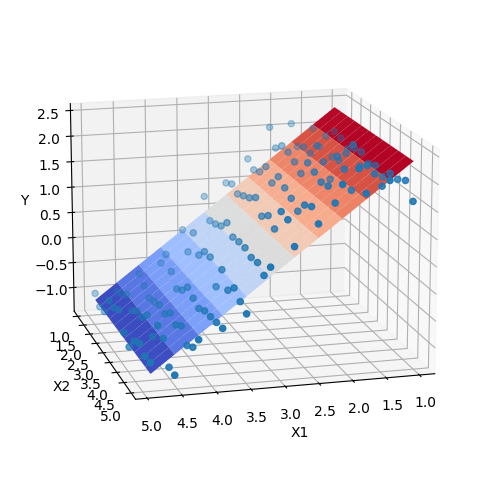

n: 1
RMSE 0.31947249351190377
número de condición: 16.462336973125918


In [5]:
n=1
Xn,c=fun_1_1(X,y,n)
y_pred=np.dot(Xn,c)
RMSE=fun_1_2(y,y_pred)
num_cond=fun_1_4(Xn)
fun_1_3(y_pred,n,"1")
print("n:",n)
print("RMSE",RMSE)
print("número de condición:",num_cond)

Tamaño de la matriz Xn: (144, 10)
(10, 10)
(10,)


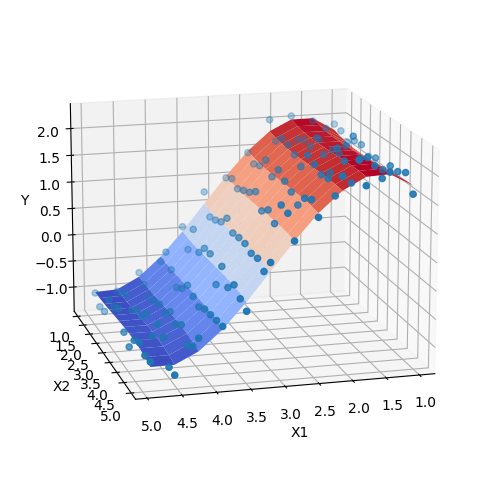

n: 3
RMSE 0.1432308849120561
número de condición: 3414.0873130573523


In [6]:
n=3
Xn,c=fun_1_1(X,y,n)
y_pred=np.dot(Xn,c)
RMSE=fun_1_2(y,y_pred)
num_cond=fun_1_4(Xn)
fun_1_3(y_pred,n,"1")
print("n:",n)
print("RMSE",RMSE)
print("número de condición:",num_cond)

Tamaño de la matriz Xn: (144, 21)
(21, 21)
(21,)


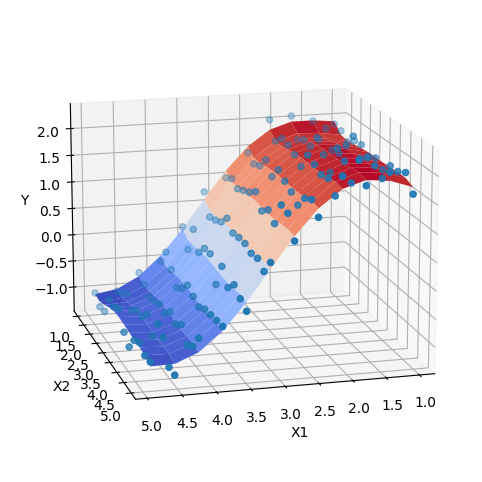

n: 5
RMSE 0.13208113620582745
número de condición: 873489.0526430887


In [7]:
n=5
Xn,c=fun_1_1(X,y,n)
y_pred=np.dot(Xn,c)
RMSE=fun_1_2(y,y_pred)
num_cond=fun_1_4(Xn)
fun_1_3(y_pred,n,"1")
print("n:",n)
print("RMSE",RMSE)
print("número de condición:",num_cond)

Tamaño de la matriz Xn: (144, 36)
(36, 36)
(36,)


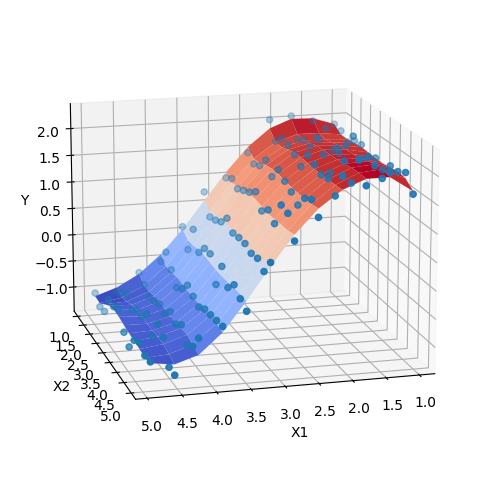

n: 7
RMSE 0.12948785893462078
número de condición: 292966220.9957492


In [8]:
n=7
Xn,c=fun_1_1(X,y,n)
y_pred=np.dot(Xn,c)
RMSE=fun_1_2(y,y_pred)
num_cond=fun_1_4(Xn)
fun_1_3(y_pred,n,"1")
print("n:",n)
print("RMSE",RMSE)
print("número de condición:",num_cond)

```



```
---

## Ejercicio 2. Mínimos cuadrados no lineales (3 puntos)

Usando los datos del Ejercicio 1, calcular los coeficientes
$\mathbf{c} = (c_0, c_1, c_2,c_3)^\top$ del modelo

$$ f(\mathbf{x}; \mathbf{c}) = f(x_1, x_2; \mathbf{c}) = c_0 + c1\sin(c_2x_1)\cos(c_3x_2) $$

resolviendo el problema de mínimos cuadrados no lineales

$$ \min_{\mathbf{c}} \; \sum_{i=1}^m  r_i(\mathbf{c})^2 $$

donde $r_i(\mathbf{c})= f(x_{1i}, x_{2i}, \mathbf{c}) - y_i$ son las
componentes del vector de residuales

$$ r(\mathbf{c}) = \begin{pmatrix}
r_1(\mathbf{c}) \\
r_2(\mathbf{c}) \\
\vdots \\
r_m(\mathbf{c})
\end{pmatrix}.
$$

1. Escriba el código de la función que evalúa el modelo $f(\mathbf{x}; \mathbf{c})$.
2. Escriba el código de la función que evalúa el residual $r(\mathbf{c})$
   para el conjunto de datos del Ejercicio 1.
3. Escriba el código de la función que calcula el valor de
   la matriz Jacobiana $\mathbf{J}$ del  residual $r(\mathbf{c})$,
   calculando las derivadas parciales de los residuales de manera
   analítica.
4. Escriba la función que implementa el algoritmo de Levenberg-Marquart
   para resolver el problema de mínimos cuadrados no lineales
   (Algoritmo 1 de la Clase 18).
5. Pruebe el algoritmo usando:

- El punto inicial $\mathbf{c}_0 = (1.0, 1.0, 0.75, 0.5)^\top$.
- $\mu_{ref} = 0.001$.
- La tolerancia $\tau = \sqrt{m}\epsilon_m^{1/3}$.
- El máximo número de iteraciones $N=200$.

Imprima el vector $\mathbf{c}_k$, el valor $f_k$, el número de iteraciones
$k$ y la variable $res$ que indica si se cumplió la tolerancia antes de
terminar las iteraciones.

Además calcule el vector $\mathbf{y}_{pred}$, que tiene los valores
que predice el modelo en los nodos $(x_{1i}, x_{2i})$ de la retícula,
calcule el RMSE e imprima su valor.

También grafique la superficie del modelo y los datos para
observar el ajuste que hace el modelo a los datos.

6. Repita la prueba usado como punto inicial
   $\mathbf{c}_0 = (1.0, 0.5, 0.75, 0.5)^\top$.

7. Agregue un comentario sobre los resultados obtenidos con respecto a
   los resultados en el Ejercicio 1.


### Solución:

1. el código de la función que evalúa el modelo $f(\mathbf{x}; \mathbf{c})$.
2. Escriba el código de la función que evalúa el residual $r(\mathbf{c})$

In [9]:
def fun_2_1(c,x):
    f=c[0]+c[1]*np.sin(c[2]*x[:,0])*np.cos(c[3]*x[:,1])
    return f

def fun_2_2(f,y):
    r=f-y
    return r[:,np.newaxis]

3. Escriba el código de la función que calcula el valor de
   la matriz Jacobiana $\mathbf{J}$ del  residual $r(\mathbf{c})$,
   calculando las derivadas parciales de los residuales de manera
   analítica.
Sea la función

$$f(x; c) = f(x_1, x_2; c) = c_0 + c_1 \sin(c_2 x_1)\cos(c_3 x_2),$$

donde  $c = (c_0, c_1, c_2, c_3) \in \mathbb{R}^4$  es el vector de parámetros, y  $x = (x_1, x_2) \in \mathbb{R}^2$  es el vector de entrada.

Dado un conjunto de observaciones $\{(x_{1i}, x_{2i}, y_i)\}_{i=1}^m,$ definimos el vector de residuales como

$$r(c) = 
\begin{pmatrix}
r_1(c) \\
r_2(c) \\
\vdots \\
r_m(c)
\end{pmatrix}
=
\begin{pmatrix}
f(x_{1i}, x_{2i}; c) - y_1 \\
f(x_{1i}, x_{2i}; c) - y_2 \\
\vdots \\
f(x_{1i}, x_{2i}; c) - y_m
\end{pmatrix}.$$


Calculamos las derivadas parciales de cada residual \( r_i(c) \) con respecto a los parámetros:


$$\frac{\partial r_i}{\partial c_0} = 1,$$

$$\frac{\partial r_i}{\partial c_1} = \sin(c_2 x_{1i}) \cos(c_3 x_{2i}),
$$
$$
\frac{\partial r_i}{\partial c_2} = c_1 x_{1i} \cos(c_2 x_{1i}) \cos(c_3 x_{2i}),
$$
$$
\frac{\partial r_i}{\partial c_3} = -c_1 x_{2i} \sin(c_2 x_{1i}) \sin(c_3 x_{2i}).
$$

Así, el Jacobiano del vector de residuales \( r(c) \) respecto a \( c \) está dado por:

$$
Jr(c) =
\begin{pmatrix}
\frac{\partial r_1}{\partial c_0} & \frac{\partial r_1}{\partial c_1} & \frac{\partial r_1}{\partial c_2} & \frac{\partial r_1}{\partial c_3} \\
\frac{\partial r_2}{\partial c_0} & \frac{\partial r_2}{\partial c_1} & \frac{\partial r_2}{\partial c_2} & \frac{\partial r_2}{\partial c_3} \\
\vdots & \vdots & \vdots & \vdots \\
\frac{\partial r_m}{\partial c_0} & \frac{\partial r_m}{\partial c_1} & \frac{\partial r_m}{\partial c_2} & \frac{\partial r_m}{\partial c_3}
\end{pmatrix}.
$$

In [10]:
def fun_2_3(c,X):
    dim=X.shape
    #print(dim)
    par_f_c_0=np.ones(dim[0])
    par_f_c_1=np.sin(c[2]*X[:,0])*np.cos(c[3]*X[:,1])
    par_f_c_2=c[1]*X[:,0]*np.cos(c[2]*X[:,0])*np.cos(c[3]*X[:,1])
    par_f_c_3=-c[1]*X[:,1]*np.sin(c[2]*X[:,0])*np.sin(c[3]*X[:,1])
    Ja=np.array([par_f_c_0,par_f_c_1,par_f_c_2,par_f_c_3])
    #print("Ja.shape",Ja.shape)

    return Ja.T



4. Escriba la función que implementa el algoritmo de Levenberg-Marquart
   para resolver el problema de mínimos cuadrados no lineales
   (Algoritmo 1 de la Clase 18).

In [11]:
def Levenberg_Marquart(R,J,z,N,mu=0.01,tol=10**(-6),guardar=False):
    v_z=[]
    v_f=[]
    v_n_p=[]
    z_i=z
    R_i=R(z)
    J_i=J(z)
    f_i=0.5*np.dot(R_i.T,R_i)
    A=np.dot(J_i.T,J_i)

    dim=A.shape
    g=np.dot(J_i.T,R_i)
    I=np.eye(dim[0])
    mu_g=mu
    res=0
    for i in range(N):
        p_i=np.linalg.solve(A+mu*I,-g)
        n_p_i=np.linalg.norm(p_i)
        if guardar:
            v_z.append(np.copy(z_i))
            v_f.append(np.copy(f_i))
            v_n_p.append(np.copy(n_p_i))
        if n_p_i<tol:
            res=1
            break
        z_i+=p_i.flatten()
        R_i=R(z_i)
        f_ip1=0.5*np.dot(R_i.T,R_i)
        dem=-np.dot(p_i.T,g)+0.5*mu*np.dot(p_i.T,p_i)
        if np.abs(dem)<=10**(-8):
            dem=10**(-8)
        rho=(f_i-f_ip1)/dem
      
        if rho<0.25:
            mu*=2
        elif rho>0.75:
            mu/=3
        f_i=f_ip1
        J_i=J(z_i)
        A=np.dot(J_i.T,J_i)
        g=np.dot(J_i.T,R_i)
    if guardar:
        return v_z,v_f,i,res
    else:
        return z_i,f_i,i,res

5. Pruebe el algoritmo usando:

- El punto inicial $\mathbf{c}_0 = (1.0, 1.0, 0.75, 0.5)^\top$.
- $\mu_{ref} = 0.001$.
- La tolerancia $\tau = \sqrt{m}\epsilon_m^{1/3}$.
- El máximo número de iteraciones $N=200$.

Imprima el vector $\mathbf{c}_k$, el valor $f_k$, el número de iteraciones
$k$ y la variable $res$ que indica si se cumplió la tolerancia antes de
terminar las iteraciones.

Además calcule el vector $\mathbf{y}_{pred}$, que tiene los valores
que predice el modelo en los nodos $(x_{1i}, x_{2i})$ de la retícula,
calcule el RMSE e imprima su valor.

También grafique la superficie del modelo y los datos para
observar el ajuste que hace el modelo a los datos.

In [12]:

mu=0.001
dim=X.shape
ep=np.finfo(float).eps

tao=np.sqrt(dim[1])*ep**(1/3)
N=200
def fun_R(c):
    f=fun_2_1(c,X)
    return fun_2_2(f,y)
def fun_J(c):
    J=fun_2_3(c,X)
    return J


In [13]:
c_0=np.array([1.0,1.0,0.75,0.5])
z_i,f_i,i,res=Levenberg_Marquart(fun_R,fun_J,c_0,N,mu,tao)
print("z_i:",z_i)
print("f_i:",f_i)
print("i:",i)
print("res:",res)

z_i: [ 4.78333299e-01  1.48856848e+00  9.94977287e-01 -4.28106165e-06]
f_i: [[1.42347657]]
i: 29
res: 1


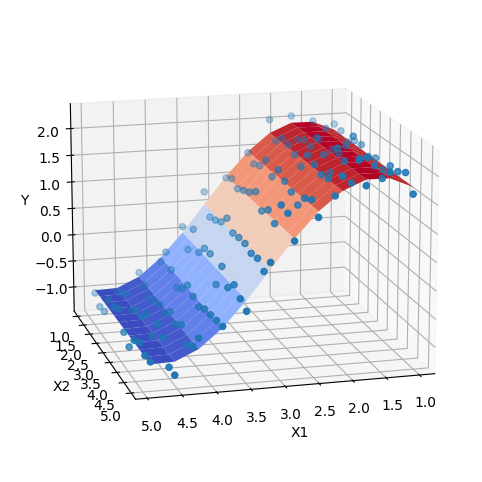

In [14]:
y_pred=fun_2_1(z_i,X)
RMSE=fun_1_2(y,y_pred)
fun_1_3(y_pred,"no lineal 1","2")

In [15]:
c_0=np.array([1.0,0.5,0.75,0.5])
z_i,f_i,i,res=Levenberg_Marquart(fun_R,fun_J,c_0,N,mu,tao)
print("z_i:",z_i)
print("f_i:",f_i)
print("i:",i)
print("res:",res)

z_i: [ 0.5972566   0.12529295 -1.92803575 16.04930368]
f_i: [[95.42917568]]
i: 38
res: 1


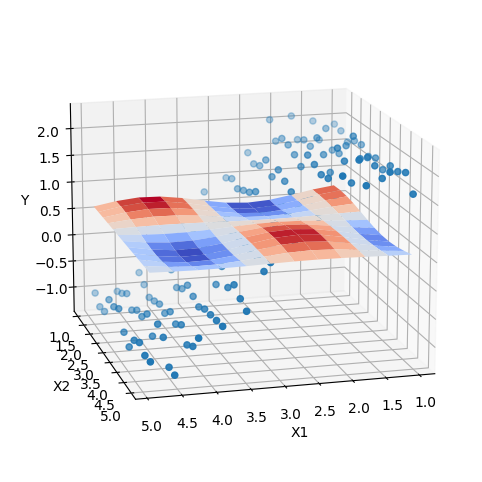

In [16]:
y_pred=fun_2_1(z_i,X)
RMSE=fun_1_2(y,y_pred)
fun_1_3(y_pred,"no lineal 2","2")

## 7.- Comentario
Se puede observar que el método depende del punto inicial dado para lograr una buena aproximación. Además, al tratarse de funciones no lineales, los cambios bruscos afectan significativamente el resultado. Comparado con el problema 1, los resultados que se pueden contrastar son los obtenidos a partir del polinomio de grado 3; cada uno presenta similitudes, pero con mayor precisión en este caso. La función no lineal actual incluye componentes armónicas, lo cual, al estar presente también en la función original, contribuye a una mayor precisión. Considero que los polinomios son más robustos, ya que no dependen directamente de la información de los datos.

```



```

---

## Ejercicio 3. Aproximación de derivadas (2 puntos)

Repita el Ejercicio 2 aproximando las derivadas parciales
que se utilizan para calcular la matriz Jacobiana del vector
de residuales por medio del esquema forward finite differences
de orden 1.

1. Programe la función que calcula la matriz Jacobiana del
   vector residuales. Se requiere usar el incremento $h$
   del esquema de diferencias finitas para aproximar las
   derivadas parciales:
   
$$ \frac{\partial f}{\partial c_i}(\mathbf{c}) \approx
\frac{f(\mathbf{c} + h\mathbf{e}_i) - f(\mathbf{c}) }{h}.
$$

2. Repita las pruebas del Ejercicio 2 con $h=0.00001$ y
   $h=0.001$ para ver como influye la elección del parámetro $h$
   en el resultado.
   
### Solución:


In [17]:
def fun_3_1(f,c,X,h):
    e=np.zeros_like(c)
    J=[]
    for i in range(len(c)):
        e[i]=1
        ap_par=(f(c+e*h,X)-f(c,X))/h
        e[i]=0
        J.append(ap_par)
    J=np.array(J)
    return J.T




In [18]:
mu=0.001
dim=X.shape
ep=np.finfo(float).eps

tao=np.sqrt(dim[1])*ep**(1/3)
N=200
def fun_R(c):
    f=fun_2_1(c,X)
    return fun_2_2(f,y)
def fun_J(c):
    J=fun_3_1(fun_2_1,c,X,0.00001)
    return J

In [19]:
c_0=np.array([1.0,1.0,0.75,0.5])
z_i,f_i,i,res=Levenberg_Marquart(fun_R,fun_J,c_0,N,mu,tao)
print("z_i:",z_i)
print("f_i:",f_i)
print("i:",i)
print("res:",res)

z_i: [ 4.78333247e-01  1.48856850e+00  9.94977265e-01 -1.08698015e-05]
f_i: [[1.42347657]]
i: 34
res: 1


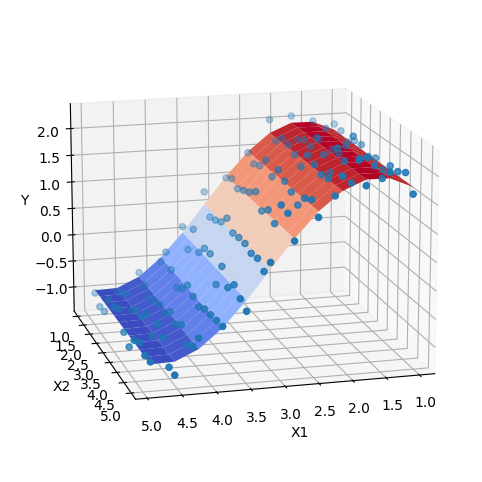

In [20]:
y_pred=fun_2_1(z_i,X)
RMSE=fun_1_2(y,y_pred)
fun_1_3(y_pred,"no lineal 1 h=0.00001","3")

In [21]:
c_0=np.array([1.0,0.5,0.75,0.5])
z_i,f_i,i,res=Levenberg_Marquart(fun_R,fun_J,c_0,N,mu,tao)
print("z_i:",z_i)
print("f_i:",f_i)
print("i:",i)
print("res:",res)

z_i: [ 0.59632996  0.04947052  1.79701567 11.71435001]
f_i: [[95.66979866]]
i: 25
res: 1


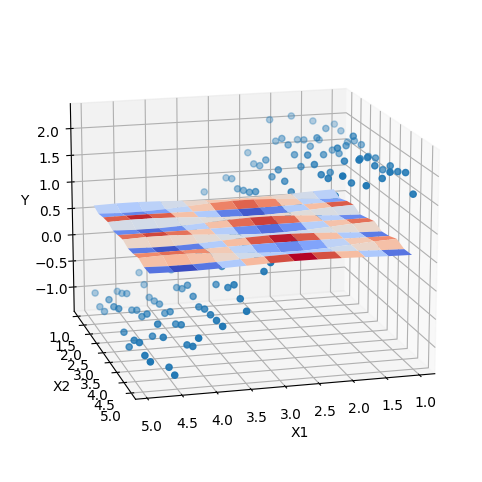

In [22]:
y_pred=fun_2_1(z_i,X)
RMSE=fun_1_2(y,y_pred)
fun_1_3(y_pred,"no lineal 2 h=0.00001","3")

In [23]:
mu=0.001
dim=X.shape
ep=np.finfo(float).eps

tao=np.sqrt(dim[1])*ep**(1/3)
N=200
def fun_R(c):
    f=fun_2_1(c,X)
    return fun_2_2(f,y)
def fun_J(c):
    J=fun_3_1(fun_2_1,c,X,0.001)
    return J

In [24]:
c_0=np.array([1.0,1.0,0.75,0.5])
z_i,f_i,i,res=Levenberg_Marquart(fun_R,fun_J,c_0,N,mu,tao)
print("z_i:",z_i)
print("f_i:",f_i)
print("i:",i)
print("res:",res)

z_i: [ 4.78330716e-01  1.48856850e+00  9.94975861e-01 -4.16027676e-04]
f_i: [[1.42347756]]
i: 52
res: 1


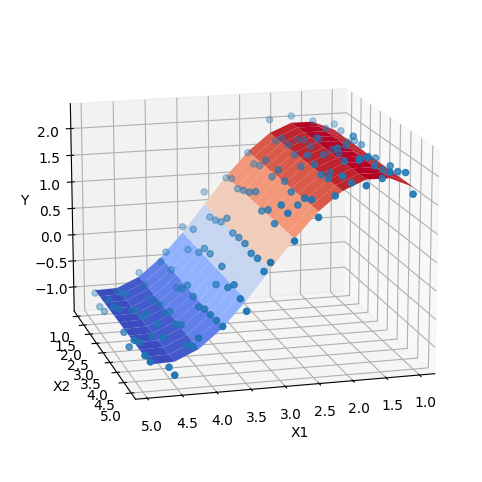

In [25]:
y_pred=fun_2_1(z_i,X)
RMSE=fun_1_2(y,y_pred)
fun_1_3(y_pred,"no lineal 1 h=0.001","3")

In [26]:
c_0=np.array([1.0,0.5,0.75,0.5])
z_i,f_i,i,res=Levenberg_Marquart(fun_R,fun_J,c_0,N,mu,tao)
print("z_i:",z_i)
print("f_i:",f_i)
print("i:",i)
print("res:",res)

z_i: [ 0.59807778 -0.17018341  1.86172715  5.23291539]
f_i: [[95.23125584]]
i: 20
res: 1


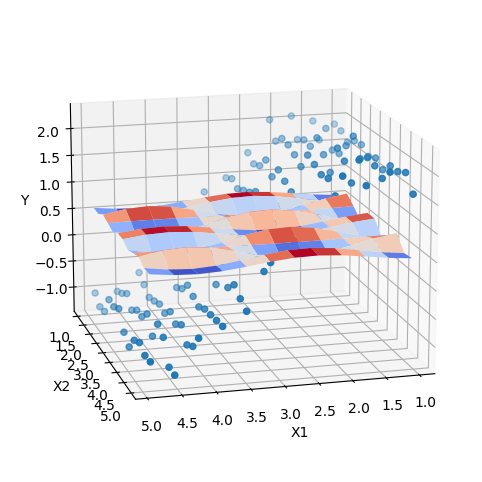

In [27]:
y_pred=fun_2_1(z_i,X)
RMSE=fun_1_2(y,y_pred)
fun_1_3(y_pred,"no lineal 2 h=0.001","3")

```



```
----

## Ejercicio 4. Algoritmo BFGS (3 puntos)

Programe el algoritmo BFGS modificado y realice las pruebas
para ver su desempeño.

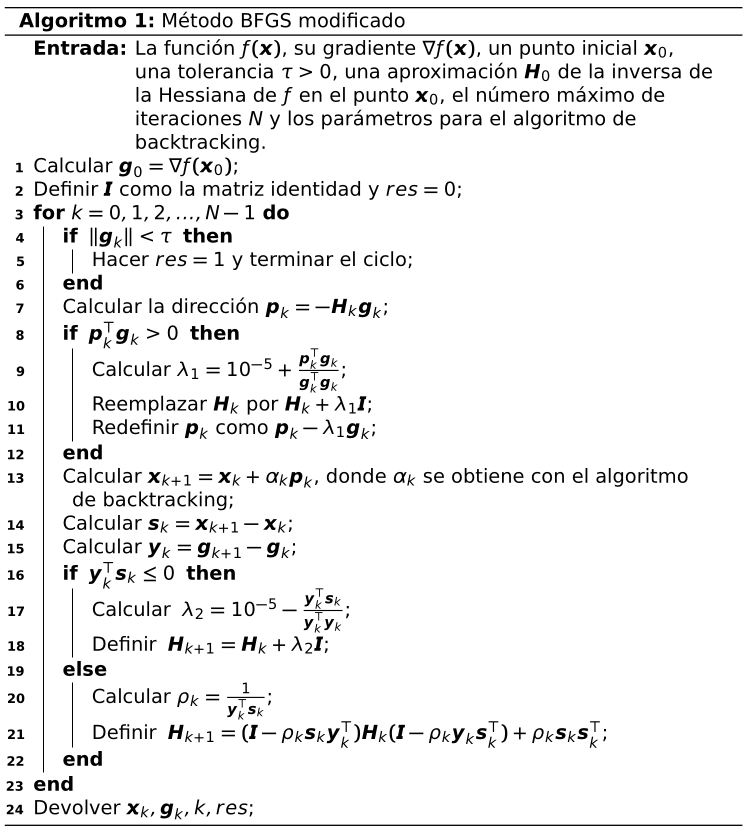

Las modificaciones que se hacen al algoritmo BFGS sirven cuando
la matriz $\mathbf{H}_k$ no es definida positiva, por lo que no
se puede garantizar que $\mathbf{p}_k$ sea una dirección de descenso.
En ese caso se puede perturbar la matriz para reemplazarla  por
$\mathbf{H}_{k} + \lambda_1\mathbf{I}$, pero la perturbación
sólo garantiza que la dirección  $\mathbf{p}_k$  resultante cumpla
con que $\mathbf{p}_{k}^\top\mathbf{g}_{k}<0$, que es indespensable
para el algoritmo de backtracking, pero no garantiza que la matriz
sea definida positiva. Por eso es que solo se aplica la fórmula
para actualizar la matriz $\mathbf{H}_{k}$ sólo si
$\mathbf{y}_{k}^\top\mathbf{s}_{k} > 0$,
y en caso contrario, se prefiere volver a perturbar la matriz.

1. Programe la función que implementa el algoritmo BFGS modificado.
   Si la dimensión de las variables es 2, almacene
   los puntos $\mathbf{x}_0, \mathbf{x}_1,...,\mathbf{x}_k$ que genera el algoritmo
   y haga que la función devuelva esta lista para usarlos para graficar la trayectoria.
2. Pruebe el algoritmo con las funciones siguientes
   usando

- los puntos iniciales $\mathbf{x_0}$ indicados,
- definir $\mathbf{H}_{0}$ como la matriz identidad,
- el número de iteraciones máximas $N=10000$ y la tolerancia
- $\tau = \sqrt{n\epsilon_m}$, donde $\epsilon_m$ es el épsilon de máquina.
- Para el algoritmo del backtraking use $\alpha_{ini}=1$, $c_1=0.1$, $\rho=0.6$ y el máximo de iteraciones $N_b=100$.

  Una vez que se haya ejecutado el algoritmo imprima los valores siguientes:
  
- $f(\mathbf{x}_0)$,
- el número de iteraciones $k$,
- la norma $\|\mathbf{g}_k\|$.
- Sea $n$ la dimensión de la variable $\mathbf{x}$. Si $n<=6$, imprimir
  el vector $\mathbf{x}_k$. En caso contrario, imprimir las primeras y
  las últimas 3 componentes de  $\mathbf{x}_k$.
- $f(\mathbf{x}_k)$.

   Además, si $n=2$, grafique los contornos de nivel de la función
   y la trayectoria  definida por los puntos $\mathbf{x}_0, \mathbf{x}_1,...,\mathbf{x}_k$.
   
3. Escriba un comentario sobre el desempeño del algoritmo BFGS comparado
   con el método de Newton implementado en el Ejercicio 3 de la Tarea 6.

### Funciones de prueba


**Función de Beale :** Para $\mathbf{x}=(x_1,x_2)$

$$f(\mathbf{x}) = (1.5-x_1 + x_1x_2)^2 + (2.25 - x_1 + x_1x_2^2)^2 + (2.625 - x_1 + x_1x_2^3)^2.$$
- $\mathbf{x}_0 = (2,3)$  
   
---

**Función de Himmelblau:** Para $\mathbf{x}=(x_1,x_2)$

$$f(\mathbf{x}) = (x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2. $$
- $\mathbf{x}_0 = (2,4)$

---

**Función de Hartmann de dimensión 6 ([Referencia](https://www.sfu.ca/~ssurjano/hart6.html)):**
Para $\mathbf{x}=(x_1,x_2, ..., x_6)$

$$ f(\mathbf{x}) = -\frac{1}{1.94} \left[ 2.58 +
\sum_{i=1}^{4} \alpha_i \exp\left(-\sum_{i=1}^{6}a_{ij}(x_j-p_{ij})^2 \right)\right],$$
donde
$$ \alpha = (1.0, 1.2, 3.0, 3.2)$$

$$ \mathbf{A} = [a_{ij}] = \begin{bmatrix}
10   &   3 &   17 & 3.5 & 1.7 &  8 \\
0.05 &  10 &   17 & 0.1 & 8   & 14 \\
3    & 3.5 & 1.7  & 10  & 17  & 8  \\
17   & 8   & 0.05 & 10  & 0.1 & 14
\end{bmatrix},$$

$$
\mathbf{P} = [p_{ij}] = 10^{-4} \begin{bmatrix}
1312 & 1696 & 5569 &  124 & 8283 & 5886 \\
2329 & 4135 & 8307 & 3736 & 1004 & 9991 \\
2348 & 1451 & 3522 & 2883 & 3047 & 6650 \\
4047 & 8828 & 8732 & 5743 & 1091 & 381
\end{bmatrix}.
$$

Esta función tiene 6 óptimos locales. El óptimo global es
$\mathbf{x}_* = (0.20169, 0.15001,  0.476874, 0.275332, 0.311652, 0.6573)$,
y $f(\mathbf{x}_*) = -3.0424$.

---

**Función de Rosenbrock:** Para $\mathbf{x}=(x_1,x_2, ..., x_n)$

$$ f(\mathbf{x}) = \sum_{i=1}^{n-1} \left[100(x_{i+1} - x_i^2)^2 + (1-x_i)^2 \right]
\quad n\geq 2.$$
- $\mathbf{x}_0 = (-1.2, 1.0)\in \mathbb{R}^{2}$  
- $\mathbf{x}_0 = (-1.2, 1.0, ..., -1.2, 1.0) \in \mathbb{R}^{200}$  
- $\mathbf{x}_0 = (-1.2, 1.0, ..., -1.2, 1.0) \in \mathbb{R}^{600}$


### Solución:

In [28]:

def fun_beale(x):
    return (1.5-x[0]+x[0]*x[1])**2+(2.25-x[0]+x[0]*x[1]**2)**2+(2.625-x[0]+x[0]*x[1]**3)**2

def grad_fun_beale(x):
    df_dx=2*(1.5-x[0]+x[0]*x[1])*(-1+x[1])+2*(2.25-x[0]+x[0]*x[1]**2)*(-1+x[1]**2)+2*(2.625-x[0]+x[0]*x[1]**3)*(-1+x[1]**3)

    df_dy=2*(1.5-x[0]+x[0]*x[1])*x[0]+2*(2.25-x[0]+x[0]*x[1]**2)*(2*x[1]*x[0])+2*(2.625-x[0]+x[0]*x[1]**3)*(3*x[0]*x[1]**2)
    return np.array([df_dx,df_dy])

def Hess_fun_beale(x):
    d2f_d2x=2*(-1+x[1])**2+2*(-1+x[1]**2)**2+2*(-1+x[1]**3)**2
    d2f_dxdy=2*x[0]*(-1+x[1])+2*(1.5-x[0]+x[0]*x[1])+4*x[0]*x[1]*(-1+x[1]**2)+4*x[1]*(2.25-x[0]+x[0]*x[1]**2)+6*x[0]*(x[1]**2)*(-1+x[1]**3)+6*(x[1]**2)*(2.625-x[0]+x[0]*x[1]**3)
    d2f_d2y=2*x[0]**2+8*(x[0]**2)*(x[1]**2)+18*(x[0]**2)*(x[1]**4)
    return np.array([[d2f_d2x,d2f_dxdy],[d2f_dxdy,d2f_d2y]])


In [29]:
def fun_Himmelbau(x):
    return (x[0]**2+x[1]-11)**2+(x[0]+x[1]**2-7)**2

def grad_fun_Himmelbau(x):
    df_dx=2*(x[0]**2+x[1]-11)*(2*x[0])+2*(x[0]+x[1]**2-7)


    df_dy=2*(x[0]**2+x[1]-11)+2*(x[0]+x[1]**2-7)*(2*x[1])

    return np.array([df_dx,df_dy])

def Hess_fun_Himmelbau(x):
    d2f_d2x=12*x[0]**2+4*x[1]-42
    d2f_dxdy=4*x[0]+4*x[1]
    d2f_d2y=12*x[1]**2+4*x[0]-26
    return np.array([[d2f_d2x,d2f_dxdy],[d2f_dxdy,d2f_d2y]])

In [30]:
A=np.array([
    [  10,   3,   17, 3.5, 1.7,  8],
    [0.05,  10,   17, 0.1,   8, 14],
    [   3, 3.5,  1.7,  10,  17,  8],
    [  17,   8, 0.05,  10, 0.1, 14]
])
P=10**(-4)*np.array([
[1312, 1696, 5569,  124, 8283, 5886],
[2329, 4135, 8307, 3736, 1004, 9991],
[2348, 1451, 3522, 2883, 3047, 6650],
[4047, 8828, 8732, 5743, 1091,  381]
])
alpha=np.array([1,1.2,3,3.2])

def exp_term(x, alpha,A,P):
    return alpha*np.exp(-np.sum(A*(x-P)**2,axis=1))

def fun_hartmann(x,alpha,A,P):
    ve=exp_term(x,alpha,A,P)
    return -(2.58+np.sum(ve))/1.94

def grad_fun_hartmann(x,alpha,A,P):
    ve=exp_term(x,alpha,A,P)
    grad=-np.sum(ve[:,np.newaxis]*(-2*A*(x-P)),axis=0)/1.94
    return grad
def hess_hartmann(x,alpha,A,P):
    ve = exp_term(x,alpha,A,P)
    dim = len(x)
    H = np.zeros((dim,dim))
    for i in range(dim):
        for j in range(dim):
            if i==j:
                H[i,j]=-np.sum(ve*((-2*A[:,i]*(x[i]-P[:,i]))**2-2*A[:,i]))/1.94
            else:
                H[i,j]=-np.sum(ve*(4*A[:,i]*A[:, j]*(x[i]-P[:,i])*(x[j]-P[:,j])))/1.94
    return H


In [31]:
def fun_Rosenbrock(x):
    fu=np.sum(100*(x[1:]-x[:-1]**(2))**(2)+(1-x[:-1])**(2),axis=0)
    return fu
def gra_fun_Rosenbrock(x):
    dim=x.shape[0]
    ja_fu=np.zeros(dim)
    ja_fu[0]=-400*(x[1]-x[0]**2)*x[0]-2*(1-x[0])
    ja_fu[1:-1]=200*(x[1:-1]-x[:-2]**2)-400*(x[2:]-x[1:-1]**2)*x[1:-1]-2*(1-x[1:-1])**2
    ja_fu[-1]=200*(x[-1]-x[-2]**2)
    return ja_fu
def Hess_fun_Rosenbrock(x):
    dim=x.shape[0]
    itera=np.arange(dim)
    He_fu=np.zeros((dim,dim))

    He_fu[itera[1:],itera[:-1]]=-400*x[:-1]
    He_fu[itera[:-1],itera[1:]]=-400*x[:-1]
    He_fu[itera[:-1],itera[:-1]]=-400*(x[1:]-x[:-1]**2)+800*x[:-1]**2+2
    He_fu[-1,-1]=200
    return He_fu

In [32]:
def backtracking(fun,x,fun_xk,p,grad_xk,alpha,c_1,rho,inter_b):
    alpha_i=np.copy(alpha)
    for i in range(inter_b):
        fun_alphai=fun(x+alpha_i*p)
        cond=fun_alphai<=fun_xk+c_1*alpha_i*np.dot(grad_xk,p)
        if cond:
            return  alpha_i, i
        alpha_i*=rho
    return  max(alpha_i,1e-8), i

def BFGS_mod( f,g,H,tao,N,x,alpha,c_1,inter_b,rho_back,lambda_1=10**(-5),lambda_2=10**(-5),guardar=False):
    v_x=[]
    v_g=[]
    v_f=[]
    x_i=x
    f_i=f(x)
    g_i=g(x_i)
    H_i=np.copy(H)
    dim=H.shape
    I=np.eye(dim[0])
    res=0
    alpha_g=np.copy(alpha)
    for i in range(N):
        alpha=np.copy(alpha_g)
        n_g_i=np.linalg.norm(g_i)
        if guardar:
            v_x.append(np.copy(x_i))
            v_g.append(np.copy(g_i))
            v_f.append(np.copy(f_i))
        if n_g_i<tao:
            res=1
            break
        p_i=-np.dot(H_i,g_i)
        pg=np.dot(p_i,g_i)
        if pg>0:
            gg=np.dot(g_i,g_i)
            lambda_1=10**(-5)+pg/gg
            H_i+=lambda_1*I
            p_i-=lambda_1*g_i
        alpha,j=backtracking(f,x_i,f_i,p_i,g_i,alpha,c_1,rho_back,inter_b)
        x_ip1=x_i+alpha*p_i
        s_i=x_ip1-x_i
        g_ip1=g(x_ip1)
        y_i=g_ip1-g_i
        ys=np.dot(y_i,s_i)
        if ys<=0: 
            lambda_2=10**(-5)-ys/np.dot(y_i,y_i)
            H_i+=lambda_2*I
        else:
            rho=1/ys
            sy=np.outer(s_i,y_i)
            sy_o=np.outer(y_i,s_i)
            H_i=np.dot(I-rho*sy,np.dot(H_i,(I-rho*sy_o)))+rho*np.outer(s_i,s_i)
        x_i=x_ip1
        g_i=g_ip1
        f_i=f(x_i)

    if guardar:
        return  x_i,g_i,f_i,i,np.array(v_x),np.array(v_g),np.array(v_f),res
    else:
        return x_i,g_i,f_i,i,res

In [33]:
import time as tm
def prueba(nom_fu,func,grad,Hess,x_ini,guardar):
    print("resultado "+nom_fu)
    
    tm_0=tm.time()
    x_k,g_k,f_k,i,v_x,v_g,v_f,res=BFGS_mod(f=func,g=grad,H=Hess,tao=10**(-6),N=10000,x=np.copy(x_ini),
                                     alpha=1.0,c_1=0.1,inter_b=100,rho_back=0.6,guardar=guardar)
    tm_1=tm.time()
    print("time:",tm_1-tm_0)
    print("f(x_ini):",func(x_ini))
    print("iterracciones:",i)
    print("res:",res)
    print("norma de g_k",np.linalg.norm(g_k))
    if len(v_x)<=6:
        print(v_x)
    else:
        print(v_x[:3])
        print(v_x[-3:])
    print("f(x_k):",f_k)

    if len(x_ini)==2:
        x_0=np.linspace(-5,5,400)
        x_1=np.linspace(-5,5,400)
        x_0,x_1=np.meshgrid(x_0,x_1)
        fu_g=func(np.array([x_0,x_1]))
        plt.figure()
        contours=plt.contour(x_0, x_1, fu_g, levels=7, colors='black')  # Líneas de contorno
        plt.clabel(contours, inline=True, fontsize=8)
        plt.plot(v_x[:,0],v_x[:,1],label="x")
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")
        plt.title("Gráfica de "+nom_fu)
        plt.legend()
        plt.savefig("pro_4_1_"+nom_fu+".pdf")

        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(x_0, x_1, fu_g, cmap='viridis')
        fig.colorbar(surf, shrink=0.5, aspect=5)
        ax.plot(v_x[:,0],v_x[:,1],v_f,linewidth=5,label="punto evaluacion")
        # Etiquetas
        ax.set_xlabel(r'$x_0$')
        ax.set_ylabel(r'$x_1$')
        ax.set_zlabel(r'f')
        ax.set_title('Gráfica de '+nom_fu)
        plt.savefig("pro_4_2_"+nom_fu+".pdf")
        plt.show()

    plt.figure()
    plt.scatter(np.arange(len(v_g)),np.linalg.norm(v_g,axis=1),label="error")
    plt.xlabel("iteracciones")
    plt.ylabel(r"$\|\nabla f(x_k)\|$")
    plt.title(r"Gráfica $\|\nabla f(x_k)\|$ de "+nom_fu)
    plt.legend()
    plt.savefig("pro_4_3_"+nom_fu+".pdf")

resultado beale
time: 0.014687776565551758
f(x_ini): 3347.203125
iterracciones: 49
res: 1
norma de g_k 6.480830610389788e-07
[[2.         3.        ]
 [1.31366586 2.65524871]
 [1.15648847 2.45777428]]
[[3.00251258 0.50068909]
 [2.99995241 0.49999405]
 [3.00000035 0.5000001 ]]
f(x_k): 2.391002214851701e-14


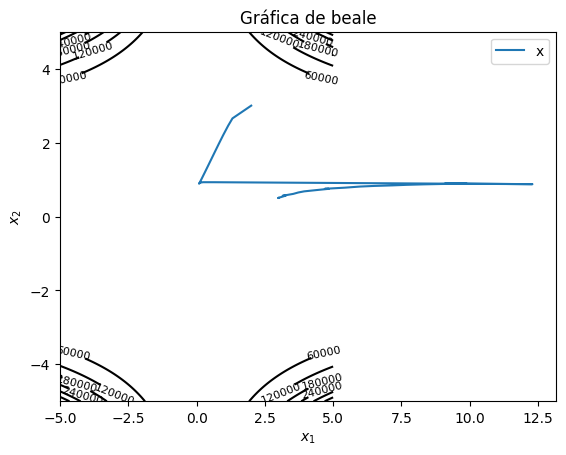

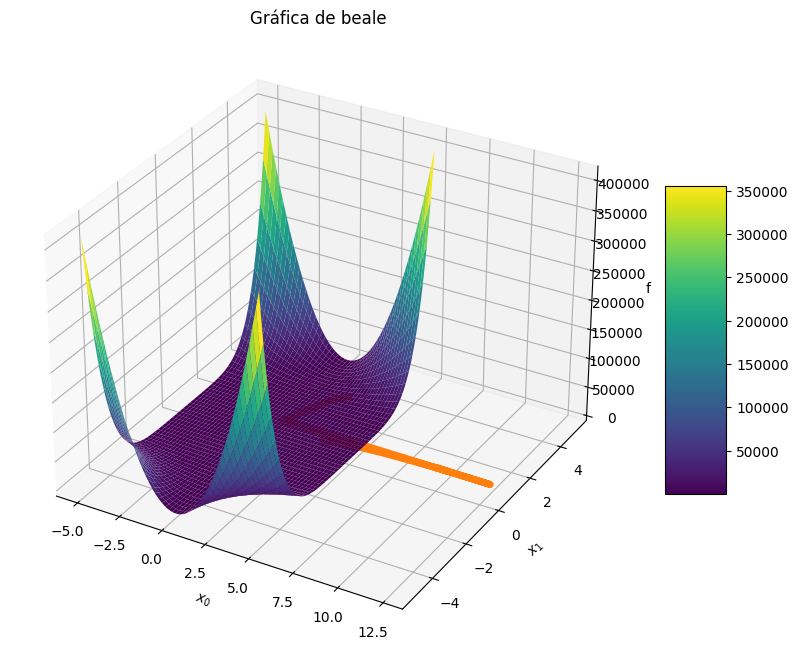

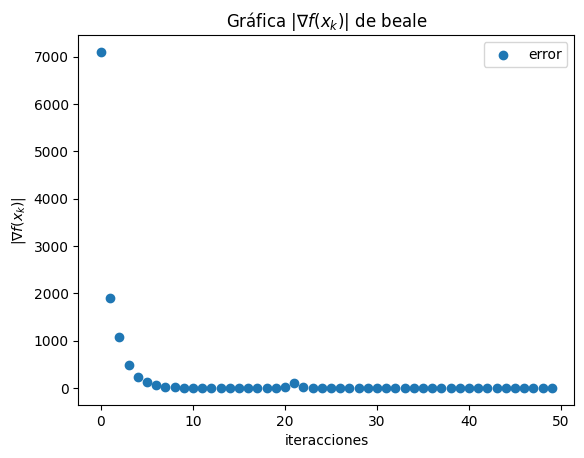

In [34]:
x_0_beale=np.array([2,3])
hess_be=Hess_fun_beale(x_0_beale)
inv_Hess_be=np.linalg.inv(hess_be)
prueba("beale",fun_beale,grad_fun_beale,inv_Hess_be,x_0_beale,True)

resultado Himmelbau
time: 0.008115053176879883
f(x_ini): 130
iterracciones: 11
res: 1
norma de g_k 9.193198413300348e-08
[[2.         4.        ]
 [3.36162362 2.83517835]
 [2.46285375 2.4379034 ]]
[[2.99999783 1.99999563]
 [3.00000004 1.99999981]
 [3.         2.        ]]
f(x_k): 1.1836488517333534e-16


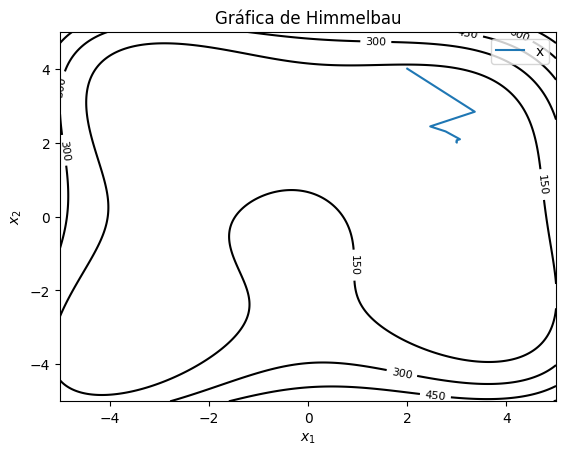

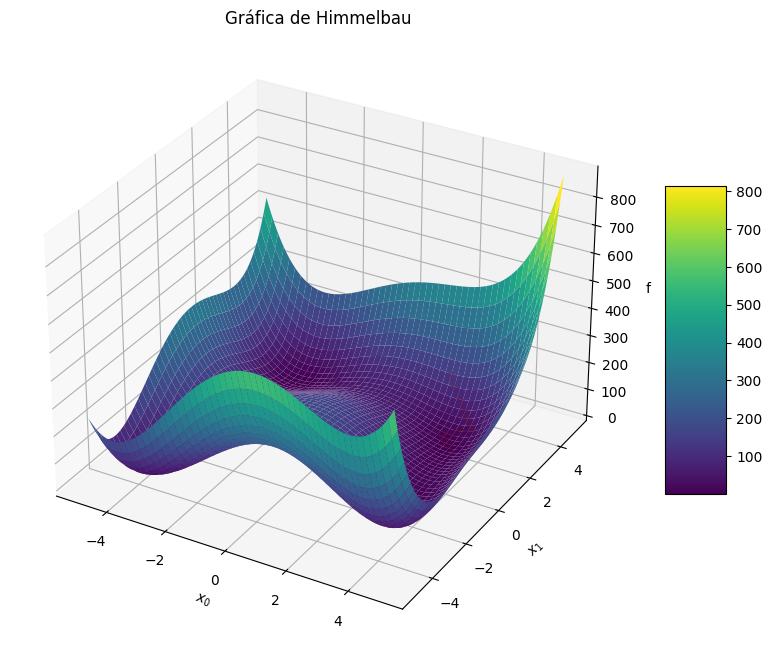

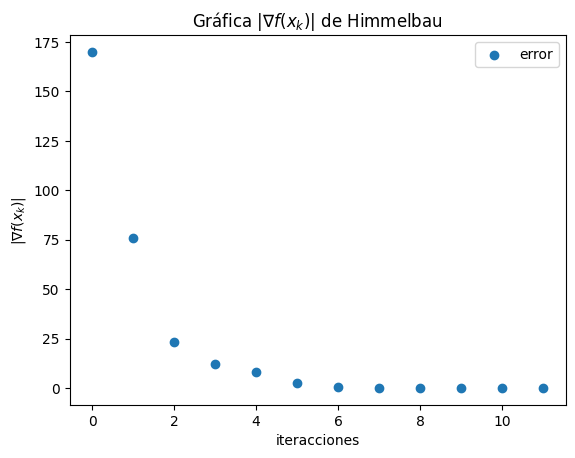

In [35]:
x_0_Himmel=np.array([2,4])
hess_Himmel=Hess_fun_Himmelbau(x_0_Himmel)
inv_Hess_Himme=np.linalg.inv(hess_Himmel)
prueba("Himmelbau",fun_Himmelbau,grad_fun_Himmelbau,inv_Hess_Himme,x_0_Himmel,True)

resultado Rosenbrock
time: 0.025393962860107422
f(x_ini): 24.199999999999996
iterracciones: 37
res: 1
norma de g_k 4.878225969120557e-09
[[-1.2         1.        ]
 [-1.1752809   1.38067416]
 [-1.15070407  1.32350819]]
[[0.99999769 0.99999502]
 [0.99999999 0.99999997]
 [1.         1.        ]]
f(x_k): 3.656209114160121e-20


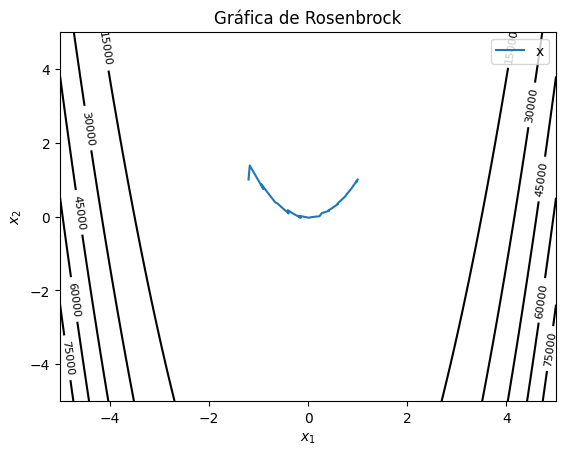

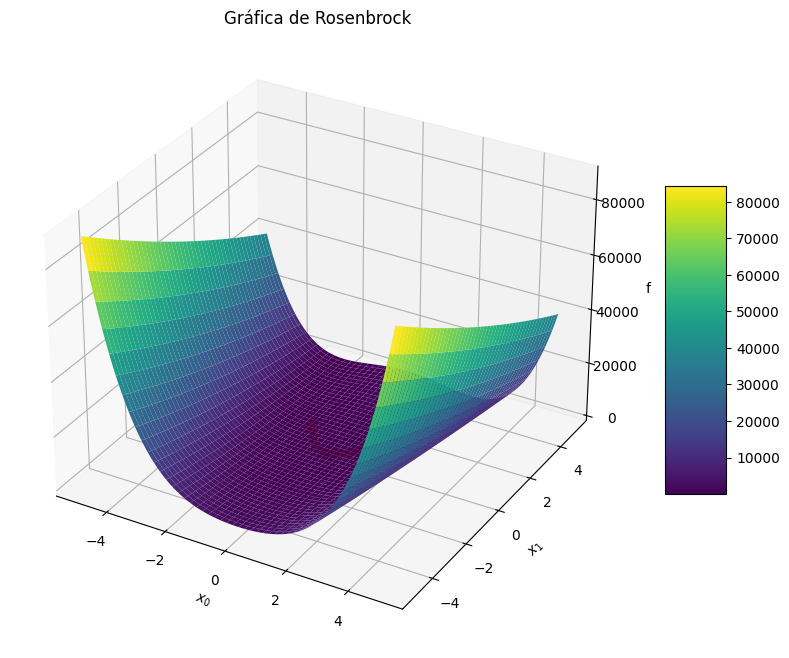

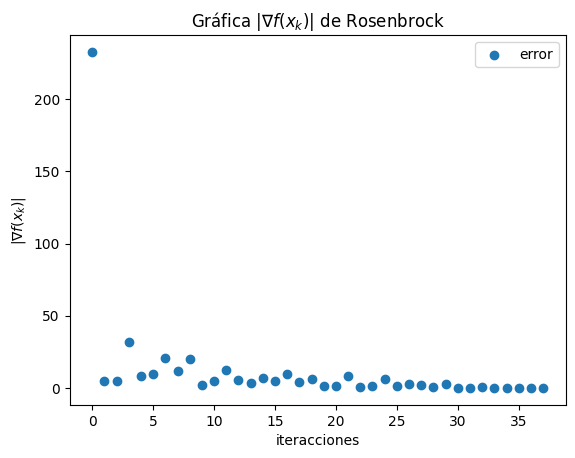

In [36]:
x_0_Rose=np.array([-1.2,1.0])
hess_Rose=Hess_fun_Rosenbrock(x_0_Rose)
inv_Hess_Rose=np.linalg.inv(hess_Rose)
prueba("Rosenbrock",fun_Rosenbrock,gra_fun_Rosenbrock,inv_Hess_Rose,x_0_Rose,True)

resultado Hartmann
time: 0.0241241455078125
f(x_ini): -1.3325201612802395
iterracciones: 21
res: 1
norma de g_k 2.8502227681654727e-07
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-7.90099353e-06 -5.39106454e-06  1.80139651e-05 -2.67538112e-06
   1.13624328e-05 -1.03836307e-05]
 [-6.42610626e-06 -4.38824557e-06  1.52366859e-05 -1.86349260e-06
   8.81199338e-06 -7.64970124e-06]]
[[0.2016886  0.15001064 0.47687898 0.27533211 0.31164954 0.65730268]
 [0.20168967 0.15001073 0.47687381 0.27533254 0.31165164 0.65730049]
 [0.2016895  0.15001069 0.47687398 0.27533242 0.31165162 0.65730054]]
f(x_k): -3.0424577378430477


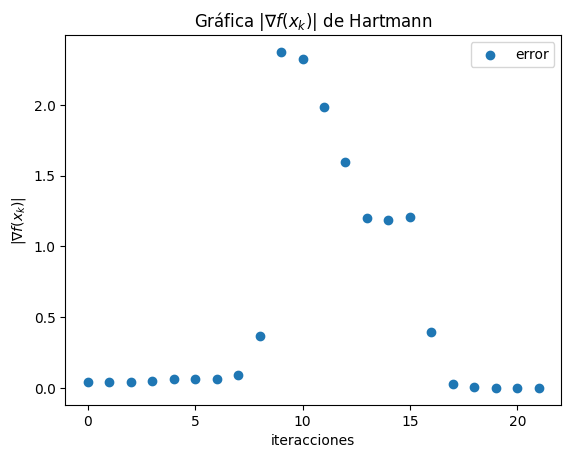

In [37]:
x_0_Hartm=np.array([0.0,0.0,0.0,0.0,0.0,0.0])
hess_Hartm=hess_hartmann(x_0_Hartm,alpha,A,P)
inv_Hess_Hartm=np.linalg.inv(hess_Hartm)
def fun_hart(x):
    return fun_hartmann(x,alpha,A,P)
def gra_hart(x):
    return grad_fun_hartmann(x,alpha,A,P)
prueba("Hartmann",fun_hart,gra_hart,inv_Hess_Hartm,x_0_Hartm,True)

resultado Rosenbrock
time: 0.8034193515777588
f(x_ini): 532.4000000000001
iterracciones: 245
res: 1
norma de g_k 8.426260570234431e-07
[[-1.2         1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.  

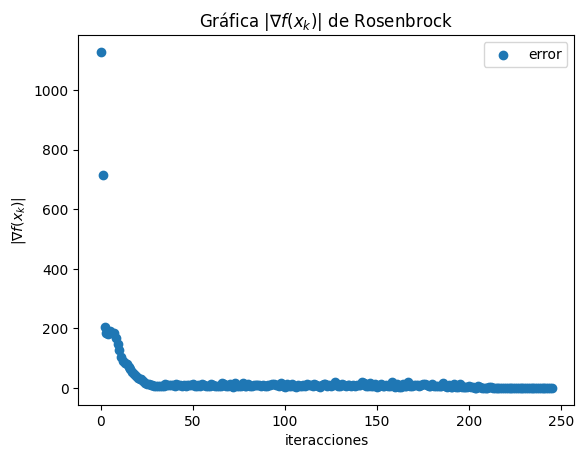

In [38]:
x_0_Rose=np.ones(200)
x_0_Rose[0]=-1.2
x_0_Rose[-2]=-1.2
hess_Rose=Hess_fun_Rosenbrock(x_0_Rose)
inv_Hess_Rose=np.linalg.inv(hess_Rose)
prueba("Rosenbrock",fun_Rosenbrock,gra_fun_Rosenbrock,inv_Hess_Rose,x_0_Rose,True)

resultado Rosenbrock
time: 10.164124727249146
f(x_ini): 532.4000000000001
iterracciones: 299
res: 1
norma de g_k 4.440895862580069e-07
[[-1.2         1.          1.         ...  1.         -1.2
   1.        ]
 [-1.14681206  1.01432509  1.01334734 ...  1.11448134 -0.03327338
  -1.64174388]
 [-0.96955197  1.03669982  1.02205331 ...  0.26881369 -0.19138696
  -0.41704724]]
[[-0.99327852  0.99663606  0.99831723 ...  0.99999066  0.99998133
   0.99996265]
 [-0.99327852  0.99663606  0.99831723 ...  0.99999374  0.99998748
   0.99997496]
 [-0.99327852  0.99663606  0.99831723 ...  0.99999544  0.99999089
   0.99998177]]
f(x_k): 3.986623938236417


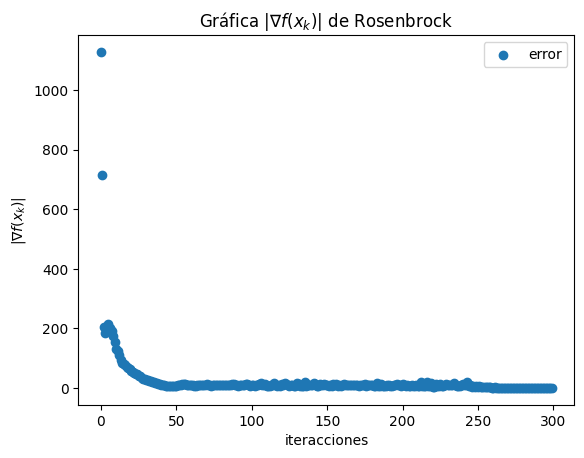

In [39]:
x_0_Rose=np.ones(600)
x_0_Rose[0]=-1.2
x_0_Rose[-2]=-1.2
hess_Rose=Hess_fun_Rosenbrock(x_0_Rose)
inv_Hess_Rose=np.linalg.inv(hess_Rose)
prueba("Rosenbrock",fun_Rosenbrock,gra_fun_Rosenbrock,inv_Hess_Rose,x_0_Rose,True)

## 3. Comentario
Al observar los resultados, se nota que el algoritmo BFGS modificado utiliza más iteraciones que el método de Newton; sin embargo, ejecuta dichas iteraciones de forma más rápida. Comparando los tiempos de convergencia, BFGS resulta ser más eficiente que Newton. Además, es importante destacar que BFGS modificado logró converger dentro del límite de 10,000 iteraciones, cosa que el método de Newton no consiguió. Por lo tanto, se puede concluir que BFGS es un algoritmo más eficiente y robusto en este contexto.